<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH08/CH08_NB04_uploadHF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Chapter 8 — Attention Optimization
## NB04: Pruning Attention Layers and Uploading to HuggingFace

[![LinkedIn](https://img.shields.io/badge/LinkedIn-blue?logo=linkedin)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-black?logo=github)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?logo=x)](https://x.com/peraborges) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-yellow)](https://huggingface.co/oopere)

**Supplementary code for the [Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models) book by [Pere Martra](https://github.com/peremartra).**

**Code repository:** [https://github.com/peremartra/Rearchitecting-LLMs](https://github.com/peremartra/Rearchitecting-LLMs)

- **Author:** Pere Martra
- **Models:** `meta-llama/Llama-3.2-3B`
- **Colab Environment:** T4 GPU
- **Keys:**
  - Attention Pruning
  - HuggingFace Hub upload
  - Automatic model card generation
- **References:**
  - [Manning Book: Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models)
  - [Not All Attention is Needed](https://arxiv.org/abs/2406.15786)

This notebook extends NB03 with two additions:
1. It computes all statistics needed for a rich model card (benchmark results,
   throughput, parameter counts, importance scores).
2. It generates the model card automatically from the run data and uploads
   the pruned model to the HuggingFace Hub.

After the upload the model is deleted from memory, reloaded from HuggingFace,
and verified with a generation test.

**Model:** `meta-llama/Llama-3.2-3B`  
**Environment:** Google Colab T4 (free tier)  

## Setting up notebook

In [ ]:
!pip install -q \
      "torch" \
      "transformers==4.55.4" \
      "accelerate==1.10.1" \
      "lm_eval==0.4.9.1" \
      "sentencepiece==0.2.1" \
      "langdetect" \
      "datasets" \
      "codecarbon" \
      "optipfair==0.2.1" \
      "huggingface_hub"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Pull the shared utility module from the chapter repository
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

In [ ]:
import os
import gc
import json
import shutil
import inspect
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from typing import Optional, Tuple
from datetime import date
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader
from utils import get_output, model_evaluation, measure_memory_allocation

In [ ]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("\u2713 Random seed set to 42")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

✓ Random seed set to 42
Using device: cuda


### Experiment configuration

All parameters that control the experiment are defined here. Set `HF_USERNAME`
to your HuggingFace account name and provide your `HF_TOKEN` (write access required).
Everything else can be left at the defaults.

In [ ]:
# --- Model & pruning ---
MODEL_NAME          = "meta-llama/Llama-3.2-3B"
NUM_LAYERS_TO_DROP  = 6                           # Attention modules to remove
CALIBRATION_SAMPLES = 400                         # Total samples across all Cosmopedia subsets
BASELINE_PROMPT     = "Paris is the capital of"

# --- HuggingFace Hub ---
HF_USERNAME = "oopere"    # <-- change to your HuggingFace username
HF_TOKEN    = None        # set your token here, or uncomment the Colab line below
# from google.colab import userdata; HF_TOKEN = userdata.get("HF_TOKEN")

# --- Benchmarks ---
RUN_BENCHMARKS      = True
BENCHMARK_LIMIT     = None
BENCHMARK_BATCH_SIZE = 4
BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa",
]

# Baseline scores for meta-llama/Llama-3.2-3B (0-shot, full eval, no limit)
# These populate the comparison table in the model card.
BASE_BENCHMARKS = {
    "arc_easy":       {"accuracy": "0.7479", "acc_norm": "0.7180"},
    "hellaswag":      {"accuracy": "0.5572", "acc_norm": "0.7405"},
    "lambada_openai": {"perplexity": "3.88",  "accuracy": "0.6969"},
    "piqa":           {"accuracy": "0.7639", "acc_norm": "0.7813"},
    "winogrande":     {"accuracy": "0.6961"},
}

## Load the model

We load Llama-3.2-3B in fp16 precision. On a T4 GPU, bfloat16 is not supported.
If you are running on an L4 or any Ampere-class GPU or newer, replace `torch.float16`
with `torch.bfloat16` for better numerical stability during calibration.

In [ ]:
# fp16: correct choice for T4 GPUs
# Switch to torch.bfloat16 if running on L4 or any Ampere-class GPU or newer
TORCH_DTYPE = torch.float16

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=TORCH_DTYPE,
    device_map=device,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
print(f"Loaded {MODEL_NAME}")

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Loaded meta-llama/Llama-3.2-3B


In [ ]:
baseline_output = get_output(model, tokenizer, BASELINE_PROMPT)
print(f"Baseline output:\n{baseline_output}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Baseline output:
 France and the largest city in the country. It is located in the north-central part of the country, on the banks of the Seine River. The city is known for its rich history, culture, and architecture. It is also a major center for business, finance, and tourism.
Paris is a city of many faces. It is a city of art and culture, a city of history and tradition, and a city of modernity and innovation. It is a city that is constantly evolving,


In [ ]:
def count_parameters(m):
    return sum(p.numel() for p in m.parameters())

params_before = count_parameters(model)
print(f"Parameters before pruning: {params_before:,}")

Parameters before pruning: 3,212,749,824


## Calibration data

Importance scores are not absolute properties of a layer — they depend on the text
the model processes. We use Cosmopedia with weighted subset sampling to ensure scores
reflect the model’s behaviour across a realistic distribution of tasks.

In [ ]:
BATCH_SIZE   = 4
MAX_LENGTH   = 2048
dataset_name = "HuggingFaceTB/cosmopedia"

# Subsets weighted to cover the same range of tasks as the benchmarks:
# stories/web activate contextual reasoning (hellaswag, winogrande),
# wikihow activates procedural understanding (piqa),
# openstax/stanford activate academic reasoning (arc_easy)
subsets = [
    ("stories",        0.300),
    ("web_samples_v2", 0.200),
    ("web_samples_v1", 0.150),
    ("wikihow",        0.150),
    ("openstax",       0.125),
    ("stanford",       0.075),
]
assert abs(sum(w for _, w in subsets) - 1.0) < 1e-6, "Weights must sum to 1.0"

all_samples = []
for subset, weight in subsets:
    n_samples = int(CALIBRATION_SAMPLES * weight)
    print(f"  Loading {subset} ({n_samples:,} samples, weight={weight:.3f})...")
    subset_data    = load_dataset(dataset_name, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(n_samples))
    all_samples.extend(subset_samples)
    print(f"    Collected {len(subset_samples):,} samples")

calibration_dataset = Dataset.from_dict({"text": [s["text"] for s in all_samples]})
print(f"\nTotal calibration samples: {len(calibration_dataset):,}")

  Loading stories (120 samples, weight=0.300)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

    Collected 120 samples
  Loading web_samples_v2 (80 samples, weight=0.200)...


...

    Collected 60 samples
  Loading openstax (50 samples, weight=0.125)...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

    Collected 50 samples
  Loading stanford (30 samples, weight=0.075)...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

    Collected 30 samples

Total calibration samples: 400


In [ ]:
def prepare_dataset(dataset, tokenizer, max_length=MAX_LENGTH, batch_size=BATCH_SIZE):
    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors=None,
        )
    tokenized = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=dataset.column_names,
    )
    def collate_fn(examples):
        input_ids      = torch.tensor([e["input_ids"]      for e in examples], dtype=torch.long)
        attention_mask = torch.tensor([e["attention_mask"] for e in examples], dtype=torch.long)
        return {"input_ids": input_ids, "attention_mask": attention_mask}

    return DataLoader(tokenized, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [ ]:
calibration_dataloader = prepare_dataset(calibration_dataset, tokenizer)
print(f"Calibration dataloader ready: {len(calibration_dataloader)} batches of {BATCH_SIZE}")

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Calibration dataloader ready: 100 batches of 4


## Measuring attention layer contribution

We use PyTorch forward hooks to capture the input (`X_A`) and output (`Y_A`) of each
attention sublayer, then compute the importance score:

```
S = 1 - CosineSim(X_A, Y_A)
```

A layer whose output is nearly identical to its input (low score) is a strong candidate
for removal. Including the residual connection in the measurement prevents us from
underestimating layers that rely on it to preserve information flow.

In [ ]:
def setup_attention_hooks(model):
    """
    Register pre-hooks to capture X_A (input to input_layernorm) and
    Y_A (input to post_attention_layernorm = X_A + Attention(LN(X_A))).
    """
    num_layers    = len(model.model.layers)
    layer_inputs  = {}
    layer_outputs = {}
    hooks         = []

    def make_input_hook(layer_idx):
        def hook(module, args):
            layer_inputs[layer_idx] = args[0].detach()
        return hook

    def make_output_hook(layer_idx):
        def hook(module, args):
            layer_outputs[layer_idx] = args[0].detach()
        return hook

    for i, layer in enumerate(model.model.layers):
        hooks.append(layer.input_layernorm.register_forward_pre_hook(make_input_hook(i)))
        hooks.append(layer.post_attention_layernorm.register_forward_pre_hook(make_output_hook(i)))

    return hooks, layer_inputs, layer_outputs, num_layers

In [ ]:
def calculate_cosine_importance(input_tensor, output_tensor, attention_mask, layer_idx, is_first_batch=False):
    if input_tensor.numel() == 0 or output_tensor.numel() == 0:
        return 0.0

    similarities   = F.cosine_similarity(input_tensor, output_tensor, dim=-1)
    attention_mask = attention_mask.to(similarities.device)
    valid_sims     = similarities * attention_mask
    n_valid        = attention_mask.sum()

    if n_valid == 0:
        return 0.0

    mean_sim = valid_sims.sum() / n_valid

    if not torch.isfinite(mean_sim):
        return 0.0

    return 1.0 - mean_sim.item()

In [ ]:
def calculate_attention_importance(model, dataloader, device):
    hooks, layer_inputs, layer_outputs, num_layers = setup_attention_hooks(model)
    accumulated_scores = {i: [] for i in range(num_layers)}

    model.eval()
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Scoring attention layers")):
            inputs = {k: v.to(device) for k, v in batch.items()}
            model(**inputs)

            for layer_idx in range(num_layers):
                if layer_idx not in layer_inputs or layer_idx not in layer_outputs:
                    raise RuntimeError(f"Hook failed for layer {layer_idx}.")
                score = calculate_cosine_importance(
                    layer_inputs[layer_idx],
                    layer_outputs[layer_idx],
                    batch["attention_mask"],
                    layer_idx,
                    is_first_batch=(batch_idx == 0),
                )
                accumulated_scores[layer_idx].append(score)

            layer_inputs.clear()
            layer_outputs.clear()

    for hook in hooks:
        hook.remove()

    final_scores = {}
    for layer_idx, scores in accumulated_scores.items():
        valid = [s for s in scores if np.isfinite(s)]
        if not valid:
            raise RuntimeError(f"No valid scores for layer {layer_idx}.")
        final_scores[layer_idx] = np.mean(valid)

    return final_scores

In [ ]:
attention_importance = calculate_attention_importance(model, calibration_dataloader, device)

print(f"\nAttention layer importance scores (ascending \u2014 lowest = most redundant):")
print(f"{'Layer':>6}  {'Score':>10}")
print("-" * 22)
for layer_idx, score in sorted(attention_importance.items(), key=lambda x: x[1]):
    print(f"{layer_idx:>6}  {score:>10.6f}")

Scoring attention layers: 100%|██████████| 100/100 [06:23<00:00,  3.83s/it]


Attention layer importance scores (ascending — lowest = most redundant):
 Layer       Score
----------------------
    21    0.009053
    22    0.010405
    23    0.012417
    20    0.012783
    18    0.014297
    24    0.014580
    25    0.015039
    19    0.019702
    16    0.020107
    17    0.023384
    26    0.029893
    15    0.036753
    14    0.051890
    13    0.062476
    10    0.063799
    27    0.064468
     8    0.065161
     6    0.066108
     5    0.067041
    12    0.069980
     4    0.072007
     9    0.073247
    11    0.075723
     7    0.088350
     3    0.090088
     2    0.099155
     1    0.139336
     0    0.287197


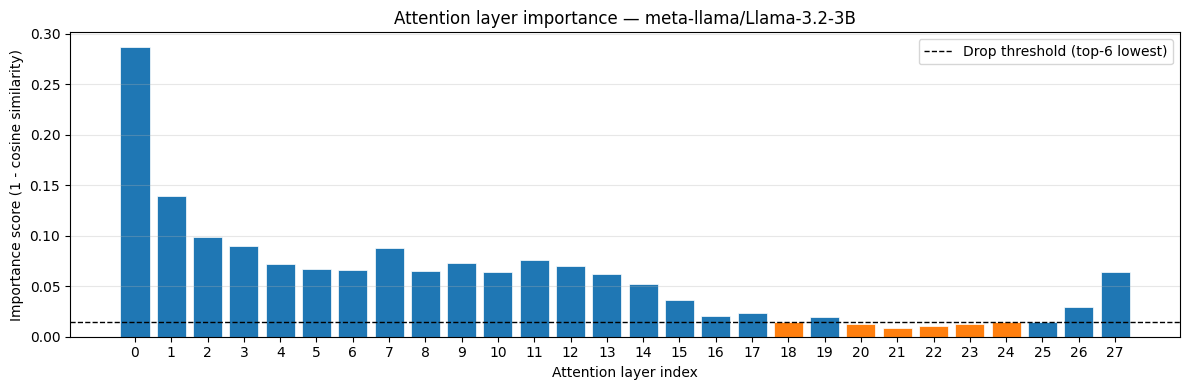

In [ ]:
def plot_attention_importance(scores, model_name, num_layers_to_drop):
    layers       = sorted(scores.keys())
    values       = [scores[l] for l in layers]
    sorted_vals  = sorted(values)
    threshold    = sorted_vals[num_layers_to_drop - 1]
    colors       = ["#ff7f0e" if v <= threshold else "#1f77b4" for v in values]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(layers, values, color=colors, edgecolor="white", linewidth=0.5)
    ax.axhline(
        y=threshold, linestyle="--", linewidth=1.0, color="black",
        label=f"Drop threshold (top-{num_layers_to_drop} lowest)",
    )
    ax.set_xlabel("Attention layer index")
    ax.set_ylabel("Importance score (1 - cosine similarity)")
    ax.set_title(f"Attention layer importance \u2014 {model_name}")
    ax.set_xticks(layers)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("attention_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_attention_importance(attention_importance, MODEL_NAME, NUM_LAYERS_TO_DROP)

## Physical deletion

We select the `NUM_LAYERS_TO_DROP` least important layers and permanently remove their
`self_attn` and `input_layernorm` submodules. The layer’s `forward()` is then patched
to route hidden states directly to the MLP block, preserving the residual connection.

In [ ]:
def select_layers_to_drop(importance_scores, num_layers_to_drop):
    sorted_layers = sorted(importance_scores.items(), key=lambda x: x[1])
    return [idx for idx, _ in sorted_layers[:num_layers_to_drop]]


def drop_attention_layer(model, layer_idx):
    """
    Physically remove self_attn and input_layernorm from a DecoderLayer
    and patch its forward() to skip the attention block entirely.
    """
    layer = model.model.layers[layer_idx]

    delattr(layer, "self_attn")
    delattr(layer, "input_layernorm")

    def forward_no_attn(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_value=None,
        use_cache: Optional[bool] = False,
        cache_position: Optional[torch.LongTensor] = None,
        position_embeddings: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
        **kwargs,
    ):
        residual     = hidden_states
        hidden_states = self.post_attention_layernorm(hidden_states)
        hidden_states = self.mlp(hidden_states)
        hidden_states = residual + hidden_states
        return hidden_states

    PrunedLayer = type("PrunedDecoderLayer", (type(layer),), {"forward": forward_no_attn})
    layer.__class__ = PrunedLayer

In [ ]:
layers_to_drop = select_layers_to_drop(attention_importance, NUM_LAYERS_TO_DROP)
print(f"Layers selected for removal: {sorted(layers_to_drop)}")

for idx in layers_to_drop:
    drop_attention_layer(model, idx)
    print(f"  Dropped attention layer {idx}")

gc.collect()
torch.cuda.empty_cache()

model.config.dropped_attn_layers = sorted(layers_to_drop)

params_after       = count_parameters(model)
param_diff         = params_before - params_after
param_pct          = param_diff / params_before * 100
param_mb           = param_diff * 2 / 1e6  # fp16 = 2 bytes per param

print(f"\nDropped layers recorded in config: {model.config.dropped_attn_layers}")
print(f"Parameters before: {params_before:,}")
print(f"Parameters after:  {params_after:,}")
print(f"Removed:           {param_diff:,}  ({param_pct:.1f}%,  ~{param_mb:.0f} MB in FP16)")

Layers selected for removal: [18, 20, 21, 22, 23, 24]
  Dropped attention layer 21
  Dropped attention layer 22
  Dropped attention layer 23
  Dropped attention layer 20
  Dropped attention layer 18
  Dropped attention layer 24

Dropped layers recorded in config: [18, 20, 21, 22, 23, 24]
Parameters before: 3,212,749,824
Parameters after:  3,061,736,448
Removed:           151,013,376  (4.7%,  ~302 MB in FP16)


In [ ]:
# Verify the architecture: pruned layers should show only mlp + post_attention_layernorm
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-17): 18 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
      (18): PrunedDecoderLayer(
        (mlp): LlamaMLP(
         

## Benchmarks

We run the standard benchmark suite on the pruned model before saving. The results
are used to populate the comparison table in the model card and to assess the
quality impact of the pruning.

Running all five benchmarks with `BENCHMARK_LIMIT = None` takes approximately
30–45 minutes on a T4 GPU. Set `RUN_BENCHMARKS = False` to skip this step
and upload the model without benchmark results in the card.

In [ ]:
if RUN_BENCHMARKS:
    print("Running benchmarks on pruned model...")
    benchmark_results = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=device, limit=BENCHMARK_LIMIT, batch_size=BENCHMARK_BATCH_SIZE,
    )
    print("\nBenchmark results:")
    for task, metrics in benchmark_results.items():
        print(f"  {task}: {metrics}")
else:
    benchmark_results = {}
    print("Skipping benchmarks (RUN_BENCHMARKS=False)")

Running benchmarks on pruned model...
Starting lm-eval on model 'meta-llama/Llama-3.2-3B' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']



Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (full dataset)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3084 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 61032/61032 [57:31<00:00, 17.68it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:50<00:00,  2.00it/s]



Benchmark results:
  arc_easy: {'accuracy': '0.7222', 'acc_norm': '0.7197'}
  hellaswag: {'accuracy': '0.5384', 'acc_norm': '0.7254'}
  lambada_openai: {'perplexity': '8.02', 'accuracy': '0.5639'}
  piqa: {'accuracy': '0.7612', 'acc_norm': '0.7715'}
  winogrande: {'accuracy': '0.6827'}


In [ ]:
# Throughput and VRAM measurement
EVAL_PROMPT = (
    "Explain in detail the history of artificial intelligence, "
    "covering all major milestones from the 1950s to the present day."
)
MAX_NEW_TOKENS = 200

throughput_results = measure_memory_allocation(
    model, tokenizer, EVAL_PROMPT, max_new_tokens=MAX_NEW_TOKENS,
)
throughput_tok_s = throughput_results.get("throughput_tokens_s", 0.0)

print(f"Throughput:   {throughput_tok_s:.2f} tok/s")
print(f"Static VRAM:  {throughput_results.get('static_vram_mb', 0):.1f} MB")
print(f"Dynamic VRAM: {throughput_results.get('dynamic_delta_mb', 0):.1f} MB")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Throughput:   9.27 tok/s
Static VRAM:  5848.4 MB
Dynamic VRAM: 29.6 MB


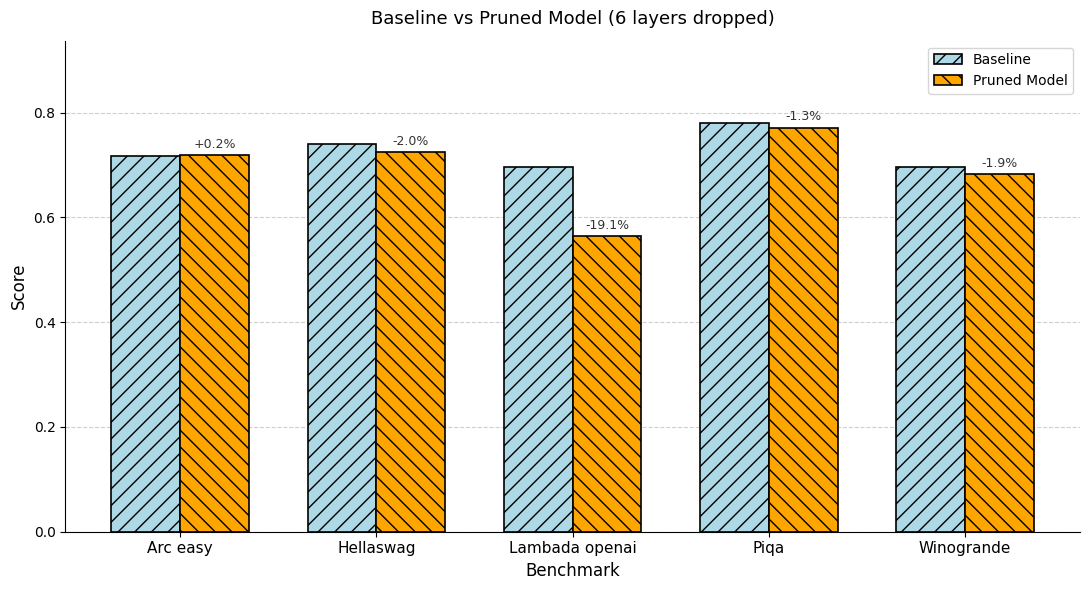

In [ ]:
if benchmark_results and BASE_BENCHMARKS:
    def get_score(d):
        return float(d.get("acc_norm", d.get("accuracy", 0)))

    common_keys   = [k for k in benchmark_results if k in BASE_BENCHMARKS]
    base_scores   = [get_score(BASE_BENCHMARKS[k])   for k in common_keys]
    pruned_scores = [get_score(benchmark_results[k]) for k in common_keys]
    deltas        = [(p - b) / b * 100 for b, p in zip(base_scores, pruned_scores)]

    fig, ax = plt.subplots(figsize=(max(7, len(common_keys) * 2.2), 6))
    bar_width = 0.35
    x = np.arange(len(common_keys))

    ax.bar(x - bar_width / 2, base_scores,   width=bar_width, color="lightblue",
           edgecolor="black", linewidth=1.2, hatch="//",  label="Baseline")
    bars_p = ax.bar(x + bar_width / 2, pruned_scores, width=bar_width, color="orange",
           edgecolor="black", linewidth=1.2, hatch="\\\\", label="Pruned Model")

    for bar, delta in zip(bars_p, deltas):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{delta:+.1f}%",
            ha="center", va="bottom", fontsize=9, color="#333333",
        )

    ax.set_xticks(x)
    ax.set_xticklabels([k.replace("_", " ").capitalize() for k in common_keys], fontsize=11)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_xlabel("Benchmark", fontsize=12)
    ax.set_title(f"Baseline vs Pruned Model ({NUM_LAYERS_TO_DROP} layers dropped)", fontsize=13, pad=12)
    ax.set_ylim(0, min(1.0, max(base_scores + pruned_scores) * 1.2))
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("benchmark_results.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No benchmark results to plot.")

## Generating the model card

The model card is generated entirely from the data computed in this run:
the actual dropped layer indices, measured importance scores, benchmark results,
throughput, and parameter counts. No values are hardcoded.

In [ ]:
def generate_model_card(
    model_name,
    model_repo_name,
    hf_repo_id,
    num_layers_to_drop,
    dropped_layers,
    importance_scores,
    params_before,
    params_after,
    benchmark_results,
    base_benchmarks,
    throughput_tok_s,
    calibration_samples,
    subsets,
):
    today = date.today().strftime("%Y-%m-%d")

    param_reduction_abs = params_before - params_after
    param_reduction_pct = param_reduction_abs / params_before * 100
    param_reduction_mb  = param_reduction_abs * 2 / 1e6
    dropped_sorted      = sorted(dropped_layers)
    dropped_str         = ", ".join(str(i) for i in dropped_sorted)

    # --- Importance scores code block ---
    sorted_scores = sorted(importance_scores.items(), key=lambda x: x[1])
    score_lines   = ["```", "Layer   Score", "------  ----------"]
    for layer_idx, score in sorted_scores[:num_layers_to_drop + 2]:
        marker = "   \u2190 dropped" if layer_idx in dropped_layers else ""
        score_lines.append(f"  {layer_idx:>3}    {score:.6f}{marker}")
    score_lines.append("  ...")
    for layer_idx, score in sorted_scores[-2:]:
        score_lines.append(f"  {layer_idx:>3}    {score:.6f}")
    score_lines.append("```")
    score_block = "\n".join(score_lines)

    # --- Benchmark table ---
    task_display = {
        "arc_easy":       ("ARC Easy",      "acc_norm"),
        "hellaswag":      ("HellaSwag",      "acc_norm"),
        "lambada_openai": ("LAMBADA OpenAI", "accuracy"),
        "piqa":           ("PIQA",           "acc_norm"),
        "winogrande":     ("WinoGrande",     "accuracy"),
    }

    def get_score(d):
        return float(d.get("acc_norm", d.get("accuracy", 0)))

    bench_rows = []
    for task, (display, metric) in task_display.items():
        if task in benchmark_results and task in base_benchmarks:
            base_s   = get_score(base_benchmarks[task])
            pruned_s = get_score(benchmark_results[task])
            delta    = (pruned_s - base_s) / base_s * 100
            bench_rows.append(
                f"| **{display}** | {metric} | {base_s:.4f} | {pruned_s:.4f} | {delta:+.2f}% |"
            )

    if bench_rows:
        bench_section = (
            "| Benchmark | Metric | Baseline | Pruned | \u0394 |\n"
            "| :--- | :--- | :---: | :---: | :---: |\n"
            + "\n".join(bench_rows)
        )
    else:
        bench_section = "_Benchmarks not run. Set `RUN_BENCHMARKS = True` and re-execute._"

    # --- Calibration table ---
    calib_rows = []
    for subset, weight in subsets:
        n = int(calibration_samples * weight)
        calib_rows.append(f"| {subset} | {weight:.3f} | {n} |")
    calib_section = (
        "| Subset | Weight | Samples |\n"
        "| :--- | :--- | :--- |\n"
        + "\n".join(calib_rows)
    )

    throughput_str = f"{throughput_tok_s:.2f} tok/s" if throughput_tok_s else "N/A"

    # --- Load code example ---
    load_code = (
        "```python\n"
        "from transformers import AutoModelForCausalLM, AutoTokenizer\n"
        "import torch\n\n"
        "model = AutoModelForCausalLM.from_pretrained(\n"
        f'    \"{hf_repo_id}\",\n'
        "    torch_dtype=torch.float16,\n"
        '    device_map=\"auto\",\n'
        "    trust_remote_code=True,\n"
        ")\n"
        f'tokenizer = AutoTokenizer.from_pretrained(\"{hf_repo_id}\")\n'
        "```"
    )

    sections = [
        "---",
        "license: apache-2.0",
        "datasets:",
        "- HuggingFaceTB/cosmopedia",
        "language:",
        "- en",
        "base_model:",
        f"- {model_name}",
        "tags:",
        "- optipfair",
        "- rearchitecting-llms",
        "- attention-pruning",
        "- small-language-model",
        "- educational",
        "---",
        f"# {model_repo_name}",
        "",
        "## Model Description",
        "",
        f'This model is a surgically optimized version of **{model_name}**, created as part of **Chapter 8** in the book **\"Rearchitecting LLMs\"**.',
        "",
        "* **Book:** [Rearchitecting LLMs](https://hubs.la/Q04k2VyY0)",
        "* **Framework:** [OptiPFair](https://github.com/peremartra/optipfair)",
        "* **Technique:** Attention Optimization (Physical Attention Layer Removal)",
        "* **Chapter:** Chapter 8 - Attention Optimization",
        "* **Notebook:** [CH08_NB04_uploadHF](https://github.com/peremartra/Rearchitecting-LLMs/blob/main/CH08/CH08_NB04_uploadHF.ipynb)",
        "* **Paper:** [What Matters in Transformers? Not All Attention is Needed](https://arxiv.org/abs/2406.15786) \u2014 He et al., 2024",
        "",
        "[![linkedin-profile-banner-martra](https://cdn-uploads.huggingface.co/production/uploads/640f7924f2d7c41a1e9eced1/sa4ivCbm8kk6C9NAPmb-x.jpeg)](https://hubs.la/Q04k2VyY0)",
        "",
        "---",
        "",
        "## Implementation",
        "",
        "### How It Works",
        "",
        f"Unlike KV cache quantization, this technique **permanently removes** the least important "
        f"attention modules from the model architecture. {num_layers_to_drop} attention layers "
        f"were removed (indices: {dropped_str}).",
        "",
        "The importance metric is:",
        "",
        "```",
        "S = 1 - CosineSim(X_A, Y_A)",
        "```",
        "",
        "Where `X_A` is the hidden state entering the attention sublayer (captured before "
        "`input_layernorm`) and `Y_A` is the hidden state after the attention computation "
        "and its residual connection (`X_A + Attention(LayerNorm(X_A))`).",
        "",
        "### Calibration Data",
        "",
        f"Importance scores were computed over **{calibration_samples} samples** from "
        "[Cosmopedia](https://huggingface.co/datasets/HuggingFaceTB/cosmopedia), "
        "weighted to cover the same range of tasks as the evaluation benchmarks:",
        "",
        calib_section,
        "",
        "### Layer Importance Scores",
        "",
        "Attention importance scores (ascending \u2014 lowest = most redundant):",
        "",
        score_block,
        "",
        "### Physical Deletion",
        "",
        f"Layers {dropped_str} were physically removed. For each selected `LlamaDecoderLayer`, "
        "`self_attn` and `input_layernorm` are deleted and the layer\'s `forward()` is patched "
        "to route hidden states directly to the MLP block:",
        "",
        "```python",
        "def forward_no_attn(self, hidden_states, ...):",
        "    residual      = hidden_states",
        "    hidden_states = self.post_attention_layernorm(hidden_states)",
        "    hidden_states = self.mlp(hidden_states)",
        "    hidden_states = residual + hidden_states",
        "    return hidden_states",
        "```",
        "",
        f"**Parameters removed:** {param_reduction_abs:,} (~{param_reduction_mb:.0f}\u00a0MB in FP16, {param_reduction_pct:.1f}% reduction)",
        "",
        "---",
        "",
        "## Loading the Model",
        "",
        load_code,
        "",
        "> **Note:** This model was developed and tested on a **Google Colab T4 GPU (free tier)**. "
        "Use `torch.float16` on T4; switch to `torch.bfloat16` on Ampere-class GPUs or newer.",
        "",
        "---",
        "",
        "## Benchmarks",
        "",
        bench_section,
        "",
        "---",
        "",
        "## Intended Use",
        "",
        "This model is intended as a **learning artifact** for readers of *Rearchitecting LLMs* "
        "(Chapter 8 Hands-On Lab). It demonstrates that a non-trivial fraction of attention layers "
        "in a modern LLM can be physically removed with surprisingly small benchmark loss. "
        "It is **not intended for production use**.",
        "",
        f"_Generated on {today} \u2014 `NUM_LAYERS_TO_DROP={num_layers_to_drop}` \u2014 throughput: {throughput_str}_",
    ]

    return "\n".join(sections)


# --- Build names and generate card ---
model_short_name = MODEL_NAME.split("/")[-1].lower()
model_repo_name  = f"{model_short_name}-attn-drop-{NUM_LAYERS_TO_DROP}"
HF_REPO_ID       = f"{HF_USERNAME}/{model_repo_name}"
OUTPUT_DIR       = f"./{model_repo_name}"

model_card = generate_model_card(
    model_name=MODEL_NAME,
    model_repo_name=model_repo_name,
    hf_repo_id=HF_REPO_ID,
    num_layers_to_drop=NUM_LAYERS_TO_DROP,
    dropped_layers=layers_to_drop,
    importance_scores=attention_importance,
    params_before=params_before,
    params_after=params_after,
    benchmark_results=benchmark_results,
    base_benchmarks=BASE_BENCHMARKS,
    throughput_tok_s=throughput_tok_s,
    calibration_samples=CALIBRATION_SAMPLES,
    subsets=subsets,
)

print(f"Model card generated ({len(model_card):,} chars)")
print(f"HF repo:    {HF_REPO_ID}")
print(f"Output dir: {OUTPUT_DIR}")
print("\n--- PREVIEW (first 600 chars) ---")
print(model_card[:600])

Model card generated (4,404 chars)
HF repo:    oopere/llama-3.2-3b-attn-drop-6
Output dir: ./llama-3.2-3b-attn-drop-6

--- PREVIEW (first 600 chars) ---
---
license: apache-2.0
datasets:
- HuggingFaceTB/cosmopedia
language:
- en
base_model:
- meta-llama/Llama-3.2-3B
tags:
- optipfair
- rearchitecting-llms
- attention-pruning
- small-language-model
- educational
---
# llama-3.2-3b-attn-drop-6

## Model Description

This model is a surgically optimized version of **meta-llama/Llama-3.2-3B**, created as part of **Chapter 8** in the book **"Rearchitecting LLMs"**.

* **Book:** [Rearchitecting LLMs](https://hubs.la/Q04k2VyY0)
* **Framework:** [OptiPFair](https://github.com/peremartra/optipfair)
* **Technique:** Attention Optimization (Physical Atte


## Saving the model

`save_pretrained` serializes weights and config but not Python code. We include a
custom modeling file (`modeling_pruned_llama.py`) that re-applies the attention bypass
at load time, and register it in the config’s `auto_map` so that
`AutoModelForCausalLM.from_pretrained` with `trust_remote_code=True` picks it up
automatically.

In [ ]:
modeling_code = '''
from typing import Optional, Tuple
import torch
from transformers import LlamaForCausalLM


class PrunedLlamaForCausalLM(LlamaForCausalLM):
    """
    LlamaForCausalLM with physical attention layer removal.

    At load time, reads dropped_attn_layers from the model config and
    patches the forward() of each affected DecoderLayer to skip the
    attention sublayer entirely. The MLP sublayer and its residual
    connection are preserved unchanged.
    """

    def __init__(self, config):
        super().__init__(config)
        dropped = getattr(config, "dropped_attn_layers", [])
        for idx in dropped:
            self._patch_layer(idx)

    def _patch_layer(self, layer_idx):
        """Remove attention submodules and patch forward() for one layer."""
        layer = self.model.layers[layer_idx]

        if hasattr(layer, "self_attn"):
            delattr(layer, "self_attn")
        if hasattr(layer, "input_layernorm"):
            delattr(layer, "input_layernorm")

        def forward_no_attn(
            self,
            hidden_states: torch.Tensor,
            attention_mask=None,
            position_ids=None,
            past_key_value=None,
            use_cache=False,
            cache_position=None,
            position_embeddings=None,
            **kwargs,
        ):
            if isinstance(hidden_states, tuple):
                hidden_states = hidden_states[0]
            residual      = hidden_states
            hidden_states = self.post_attention_layernorm(hidden_states)
            hidden_states = self.mlp(hidden_states)
            hidden_states = residual + hidden_states
            return hidden_states

        PrunedLayer = type(
            "PrunedDecoderLayer",
            (type(layer),),
            {"forward": forward_no_attn},
        )
        layer.__class__ = PrunedLayer
'''

with open("modeling_pruned_llama.py", "w") as f:
    f.write(modeling_code)
print("modeling_pruned_llama.py written.")

# Save weights, config, and tokenizer
model.config.auto_map = {
    "AutoModelForCausalLM": "modeling_pruned_llama.PrunedLlamaForCausalLM"
}
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
shutil.copy("modeling_pruned_llama.py", OUTPUT_DIR)

# Write model card as README.md
with open(f"{OUTPUT_DIR}/README.md", "w") as f:
    f.write(model_card)

# Verify the saved config
with open(f"{OUTPUT_DIR}/config.json") as f:
    config_dict = json.load(f)

print(f"\nSaved to: {OUTPUT_DIR}")
print(f"auto_map:            {config_dict.get('auto_map')}")
print(f"dropped_attn_layers: {config_dict.get('dropped_attn_layers')}")
print(f"README.md:           {len(model_card):,} chars")

modeling_pruned_llama.py written.

Saved to: ./llama-3.2-3b-attn-drop-6
auto_map:            {'AutoModelForCausalLM': 'modeling_pruned_llama.PrunedLlamaForCausalLM'}
dropped_attn_layers: [18, 20, 21, 22, 23, 24]
README.md:           4,404 chars


## Uploading to HuggingFace

`HfApi.upload_folder` transfers the entire model directory in a single call,
including weights, config, tokenizer files, the custom modeling module, and
the README.md model card. The repository is created automatically if it does
not exist (`exist_ok=True` prevents errors on re-runs).

In [ ]:
from huggingface_hub import HfApi, login

# Authenticate
if HF_TOKEN:
    login(token=HF_TOKEN)
else:
    # Falls back to cached credentials from `huggingface-cli login`
    login()

api = HfApi()

# Create the repository (no-op if it already exists)
api.create_repo(
    repo_id=HF_REPO_ID,
    repo_type="model",
    exist_ok=True,
    private=False,
)
print(f"Repository ready: https://huggingface.co/{HF_REPO_ID}")

# Upload the full model directory
print("Uploading model files...")
api.upload_folder(
    folder_path=OUTPUT_DIR,
    repo_id=HF_REPO_ID,
    repo_type="model",
    commit_message=f"Add {model_repo_name}: {NUM_LAYERS_TO_DROP} attention layers removed",
)
print(f"\nUpload complete: https://huggingface.co/{HF_REPO_ID}")

## Reload from HuggingFace and verify

We now delete the model from GPU memory, reload it directly from HuggingFace
using `trust_remote_code=True`, and run a generation test with `BASELINE_PROMPT`.
This confirms the full round-trip: upload, custom class registration, and inference
all work without any manual patching.

In [ ]:
print("Freeing model from GPU memory...")
del model
gc.collect()
torch.cuda.empty_cache()
print("Memory freed.")

Freeing model from GPU memory...
Memory freed.


In [ ]:
print(f"Loading pruned model from HuggingFace Hub: {HF_REPO_ID}")
hf_model = AutoModelForCausalLM.from_pretrained(
    HF_REPO_ID,
    torch_dtype=TORCH_DTYPE,
    device_map=device,
    trust_remote_code=True,
)
hf_tokenizer = AutoTokenizer.from_pretrained(HF_REPO_ID)
hf_tokenizer.pad_token = hf_tokenizer.eos_token

In [ ]:
print(f"Model loaded from HuggingFace Hub.")
print(f"Dropped layers in config: {hf_model.config.dropped_attn_layers}")

Model loaded from HuggingFace Hub.
Dropped layers in config: [18, 20, 21, 22, 23, 24]


In [ ]:
hf_output = get_output(hf_model, hf_tokenizer, BASELINE_PROMPT)
print(f"Prompt: {BASELINE_PROMPT}")
print(f"\nHuggingFace model output:")
print(hf_output)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Prompt: Paris is the capital of

HuggingFace model output:
 France. It is the largest city in France and the capital of the Île-de-France region. Paris is located in the north of France, on the river Seine. Paris is the world's most visited tourist destination, with 23 million tourists in 2013. Paris is the world's most-visited city, with 16.8 million tourists in 2011. Paris is the world's most-visited city, with 16.8 million tourists in 2011.
